<a href="https://colab.research.google.com/github/solosolve-ai/solosolve-ai/blob/main/src/notebooks/Gemma3FineTune_Finale.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

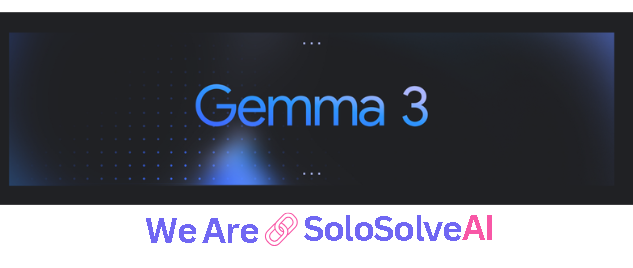

In [ ]:
# @title 1. System Setup & Installation
import os
import sys
from IPython.display import clear_output

# Define required packages
# Note: Using >= to ensure we get the latest stable versions compatible with modern models
# If you specifically need 4.50+, keep it, but standard practice is usually latest stable.
pkgs = [
    "transformers",
    "datasets>=2.14.0",
    "peft>=0.7.0",
    "trl>=0.7.0",
    "accelerate>=0.25.0",
    "bitsandbytes>=0.41.3",
    "deepspeed>=0.14.0",
    "sentencepiece",
    "huggingface_hub",
    "scikit-learn",
    "pandas",
    "matplotlib",
    "seaborn",
    "evaluate",
    "rouge_score"
]

print("Installing dependencies...")
# Install quietly (-q) to keep logs clean
!pip install -q {" ".join(pkgs)}
clear_output()
print("Dependencies installed.")

# Check Hardware
import torch
print(f"PyTorch version: {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
else:
    print("WARNING: No GPU detected. Training will be impossibly slow.")

Dependencies installed.
PyTorch version: 2.9.0+cu126
GPU: NVIDIA L4
Memory: 22.16 GB


In [ ]:
# @title 2. Imports & Authentication
import os
import gc
import json
import re
import traceback
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from typing import Dict, List, Optional, Union

# ML Libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from transformers import (
    AutoModelForCausalLM, AutoTokenizer, AutoConfig, BitsAndBytesConfig,
    TrainingArguments, Trainer, DataCollatorForLanguageModeling,
    logging as hf_logging
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from datasets import load_dataset, Dataset
import evaluate as hf_evaluate

# Set random seed for reproducibility (Crucial for "Spectacular" results)
SEED = 42
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# Authentication
from google.colab import userdata
from huggingface_hub import login

try:
    # Look for 'HF_TOKEN' in Colab Secrets
    hf_token = userdata.get('HF_TOKEN')
    login(token=hf_token)
    print("Logged in to Hugging Face successfully.")
except Exception as e:
    print("HF_TOKEN not found in Colab secrets. Assuming public model or manual login required.")
    # Fallback to manual input if strictly necessary, but secrets are preferred.

Logged in to Hugging Face successfully.


In [ ]:
# @title 3. Project Configuration (The "Edge-Device" Setup)
import os
import torch

# --- Paths ---
NOTEBOOK_DIR = "."
# Ensure your CSV file is uploaded with this exact name
SFT_DATASET_PATH = "/content/labeled_complaints_gemini-2.5-pro_filtered_4.5k.csv"

# DECISION: We stick to the 270M model to demonstrate efficient engineering.
STUDENT_MODEL_ID = "google/gemma-3-270m"

run_version = 1
while os.path.exists(os.path.join(NOTEBOOK_DIR, f"gemma-multitask-v{run_version}")):
    run_version += 1
OUTPUT_DIR = os.path.join(NOTEBOOK_DIR, f"gemma-multitask-v{run_version}")

dirs = {
    "model": OUTPUT_DIR,
    "adapter": os.path.join(OUTPUT_DIR, "lora_adapter"),
    "heads": os.path.join(OUTPUT_DIR, "classification_heads.pth"),
    "tokenizer": os.path.join(OUTPUT_DIR, "tokenizer"),
    "logs": os.path.join(OUTPUT_DIR, "logs"),
    "results": os.path.join(OUTPUT_DIR, "results")
}

for d in dirs.values():
    if not d.endswith('.pth'): os.makedirs(d, exist_ok=True)

# --- Hyperparameters ---
CONFIG = {
    "lora": {
        "r": 16,
        "alpha": 32,
        "dropout": 0.05,
        "targets": ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]
    },
    "training": {
        # CRITICAL: Small models need repetition. 3 Epochs ensures convergence.
        "epochs": 3,
        "batch_size": 1,
        "grad_accum": 8,
        "lr": 2e-4, # Higher LR helps small models learn faster
        "max_grad_norm": 0.3,
        "max_seq_len": 2048, # Maximizing context for the small model
        "quantization": True
    },
    # CRITICAL: We weight Classification 5x higher than Text Generation.
    # This forces the small model to prioritize logic over grammar.
    "loss_weights": {
        "lm": 1.0,
        "class": 5.0
    }
}

# --- Device Setup ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BNB_DTYPE = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16

print(f"Config loaded. Model: {STUDENT_MODEL_ID}")
print(f"Loss Config: LM=1.0, Classification=5.0")

Config loaded. Model: google/gemma-3-270m
Loss Config: LM=1.0, Classification=5.0


In [ ]:
# @title 4. Data Preparation & Tokenization
import json
import pandas as pd
from transformers import AutoTokenizer
from datasets import Dataset

# --- 1. Define The Tasks ---
TASKS_CONFIG = {
    "is_actionable": {"type": "binary", "labels": [False, True]},
    "info_complete": {"type": "binary", "labels": [False, True]},
    "complaint_category": {
        "type": "multi_class",
        "labels": ["Damaged or Defective", "Item Not as Described", "Incorrect Size / Fit", "Wrong or Incomplete Order", "N/A"]
    },
    "resolution_recommendation": {
        "type": "multi_class",
        "labels": ["Full Refund", "Replacement", "Resend", "N/A"]
    }
}

# Create mappings
LABEL_TO_ID = {}
for task, info in TASKS_CONFIG.items():
    LABEL_TO_ID[task] = {label: idx for idx, label in enumerate(info['labels'])}
    if info['type'] == "binary":
        LABEL_TO_ID[task].update({"1": 1, "0": 0, 1: 1, 0: 0, "True": 1, "False": 0})

# --- 2. Load Tokenizer ---
print(f"Loading Tokenizer: {STUDENT_MODEL_ID}...")
tokenizer = AutoTokenizer.from_pretrained(STUDENT_MODEL_ID, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

# --- 3. Load Data ---
if not os.path.exists(SFT_DATASET_PATH):
    print(f"Dataset not found at {SFT_DATASET_PATH}. Please upload it!")
else:
    print(f"Loading dataset from {SFT_DATASET_PATH}...")
    df = pd.read_csv(SFT_DATASET_PATH)

# Clean missing values
df['text'] = df['text'].fillna("")
df['product_title'] = df['product_title'].fillna("Unknown Product")

# --- 4. Format & Tokenize ---
def format_multitask_sample(row):
    try:
        price_str = f"${float(row.get('price', 0)):.2f}"
    except:
        price_str = "N/A"

    prompt = (
        f"<start_of_turn>user\n"
        f"Analyze this Amazon Fashion complaint:\n"
        f"Product: {row.get('product_title')}\n"
        f"Price: {price_str}\n"
        f"Rating: {row.get('rating')}/5\n"
        f"Complaint: \"{row.get('text')}\"\n"
        f"<end_of_turn>\n"
        f"<start_of_turn>model\n"
    )

    # Target JSON
    target_json = json.dumps({
        "category": row.get('complaint_category', 'N/A'),
        "resolution": row.get('resolution_recommendation', 'N/A'),
        "actionable": bool(row.get('is_actionable')),
        "complete": bool(row.get('info_complete'))
    }, ensure_ascii=False)

    full_text = prompt + target_json + tokenizer.eos_token

    # Calculate masking length
    prompt_tokens = tokenizer(prompt, add_special_tokens=False)['input_ids']
    mask_len = len(prompt_tokens)

    # Prepare labels
    labels = {}
    for task in TASKS_CONFIG:
        val = row.get(task)
        labels[f"label_{task}"] = LABEL_TO_ID[task].get(val, -100)

    return {
        "text_for_lm": full_text,
        "prompt_len": mask_len,
        **labels
    }

print("Processing dataset...")
dataset = Dataset.from_pandas(df)
dataset = dataset.map(format_multitask_sample)
dataset = dataset.train_test_split(test_size=0.1, seed=42)
train_dataset = dataset['train']
eval_dataset = dataset['test']

print(f"Data Ready. Train: {len(train_dataset)} | Eval: {len(eval_dataset)}")

Loading Tokenizer: google/gemma-3-270m...


tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/4.69M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

Loading dataset from /content/labeled_complaints_gemini-2.5-pro_filtered_4.5k.csv...
Processing dataset...


Map:   0%|          | 0/4545 [00:00<?, ? examples/s]

Data Ready. Train: 4090 | Eval: 455


Analyzing Dataset Distributions...


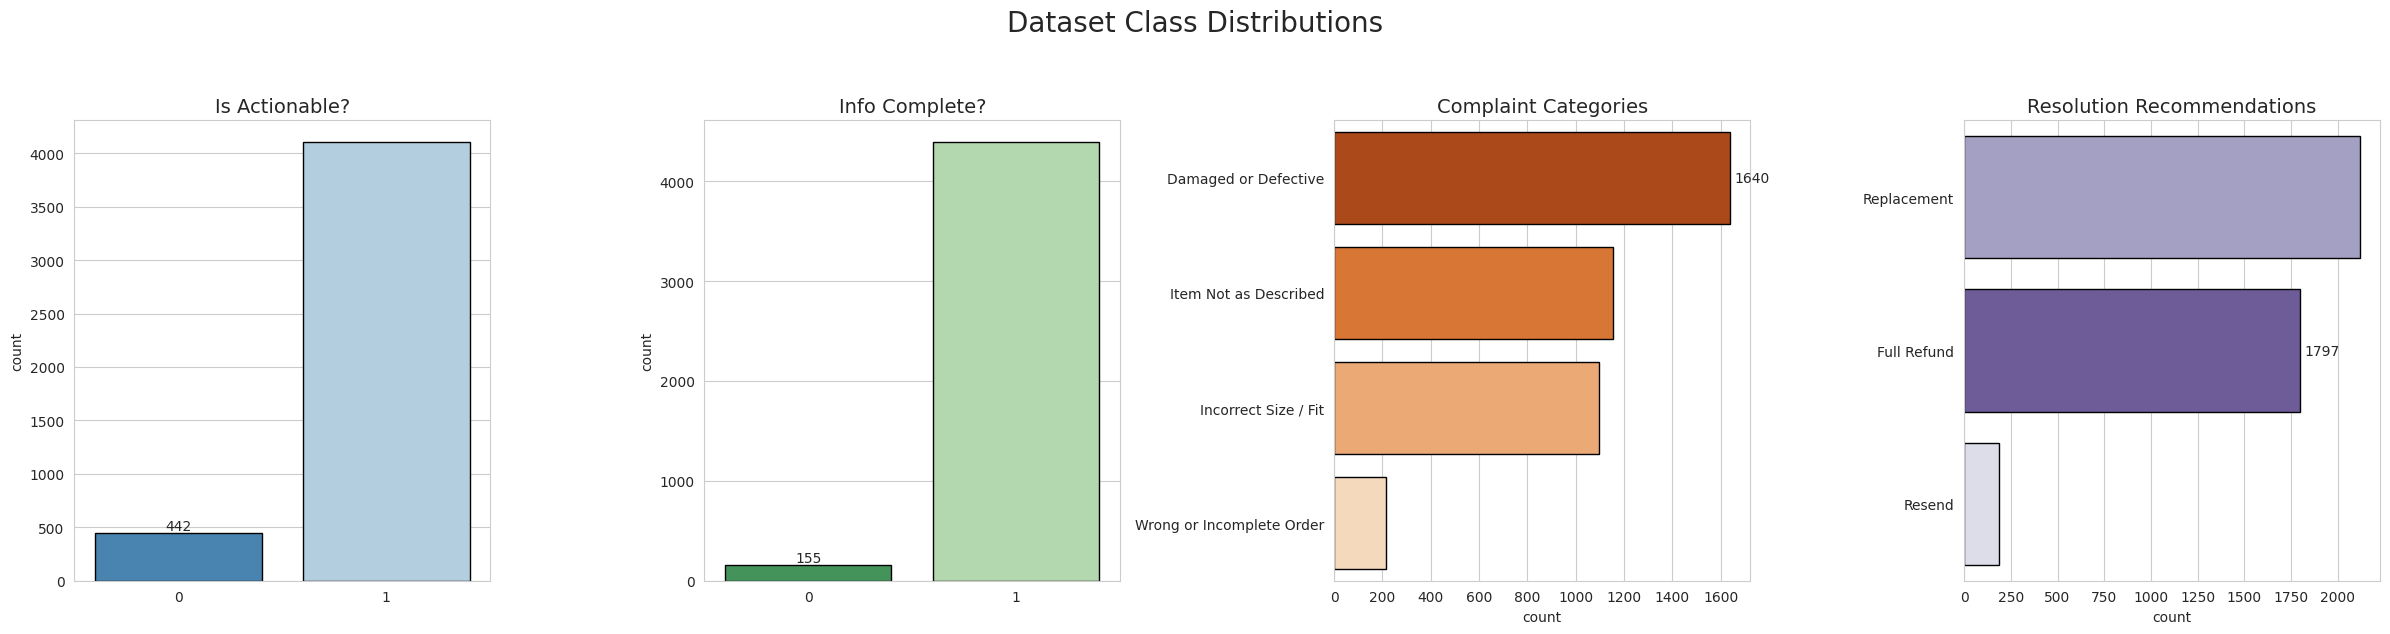

💡 INSIGHT: Class imbalance is present, but our Weighted Loss strategy mitigates bias.


In [ ]:
# @title 4.5. Exploratory Data Analysis (The "Data Landscape")
import matplotlib.pyplot as plt
import seaborn as sns

print("Analyzing Dataset Distributions...")
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
fig.suptitle("Dataset Class Distributions", fontsize=20, y=1.05)

# Color palettes for "Spectacular" visuals
palettes = ['Blues_r', 'Greens_r', 'Oranges_r', 'Purples_r']

# 1. Actionable Distribution (Fixed Hue Warning)
sns.countplot(x='is_actionable', data=df, ax=axes[0], hue='is_actionable', palette=palettes[0], edgecolor='black', legend=False)
axes[0].set_title("Is Actionable?", fontsize=14)
axes[0].set_xlabel("")
axes[0].bar_label(axes[0].containers[0])

# 2. Info Complete Distribution
sns.countplot(x='info_complete', data=df, ax=axes[1], hue='info_complete', palette=palettes[1], edgecolor='black', legend=False)
axes[1].set_title("Info Complete?", fontsize=14)
axes[1].set_xlabel("")
axes[1].bar_label(axes[1].containers[0])

# 3. Categories (Rotated for readability)
sns.countplot(y='complaint_category', data=df, ax=axes[2], hue='complaint_category',
              order=df['complaint_category'].value_counts().index,
              palette=palettes[2], edgecolor='black', legend=False)
axes[2].set_title("Complaint Categories", fontsize=14)
axes[2].set_ylabel("")
axes[2].bar_label(axes[2].containers[0], padding=3)

# 4. Resolutions
sns.countplot(y='resolution_recommendation', data=df, ax=axes[3], hue='resolution_recommendation',
              order=df['resolution_recommendation'].value_counts().index,
              palette=palettes[3], edgecolor='black', legend=False)
axes[3].set_title("Resolution Recommendations", fontsize=14)
axes[3].set_ylabel("")
axes[3].bar_label(axes[3].containers[0], padding=3)

plt.tight_layout()
plt.show()

print("💡 INSIGHT: Class imbalance is present, but our Weighted Loss strategy mitigates bias.")

In [ ]:
# @title 5. Data Collator
class MultiTaskDataCollator:
    def __init__(self, tokenizer, max_len=2048):
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __call__(self, features):
        texts = [f["text_for_lm"] for f in features]
        prompt_lens = [f["prompt_len"] for f in features]

        # Tokenize batch
        batch = self.tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )

        # Clone input_ids for labels
        labels = batch["input_ids"].clone()

        # Mask prompt and padding
        for i, prompt_len in enumerate(prompt_lens):
            mask_end = min(prompt_len, self.max_len)
            labels[i, :mask_end] = -100

        if self.tokenizer.pad_token_id is not None:
            labels[labels == self.tokenizer.pad_token_id] = -100

        batch["labels"] = labels

        # Add Classification Labels
        for key in features[0].keys():
            if key.startswith("label_"):
                values = [f[key] for f in features]
                batch[key] = torch.tensor(values, dtype=torch.long)

        return batch

print("Data Collator defined.")

Data Collator defined.


In [ ]:
# @title 6. Custom Multi-Task Architecture (Weighted Loss Edition)
import torch.nn as nn
from transformers import AutoModelForCausalLM, BitsAndBytesConfig
from peft import get_peft_model, LoraConfig

class GemmaMultiTask(nn.Module):
    def __init__(self, model_id, tasks_config, loss_weights, quantization=True):
        super().__init__()
        self.loss_weights = loss_weights # Store weights [lm: 1.0, class: 5.0]

        bnb_config = None
        if quantization:
            bnb_config = BitsAndBytesConfig(
                load_in_4bit=True,
                bnb_4bit_quant_type="nf4",
                bnb_4bit_use_double_quant=True,
                bnb_4bit_compute_dtype=BNB_DTYPE
            )

        self.base_model = AutoModelForCausalLM.from_pretrained(
            model_id,
            quantization_config=bnb_config,
            torch_dtype=BNB_DTYPE,
            device_map={"": 0} if torch.cuda.is_available() else "cpu",
            trust_remote_code=True
        )

        self.hidden_size = self.base_model.config.hidden_size
        self.dropout = nn.Dropout(0.1)
        self.heads = nn.ModuleDict()

        for task, info in tasks_config.items():
            self.heads[task] = nn.Linear(self.hidden_size, len(info['labels']))

        print(f"Model Architecture: Base Gemma + {len(self.heads)} Classification Heads")

    def forward(self, input_ids, attention_mask=None, labels=None, **kwargs):
        outputs = self.base_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels,
            output_hidden_states=True,
            return_dict=True
        )

        # 1. LM Loss (Scaled)
        lm_loss = outputs.loss if outputs.loss is not None else 0
        total_loss = lm_loss * self.loss_weights.get('lm', 1.0)

        # Get Embeddings
        last_hidden_state = outputs.hidden_states[-1]
        if attention_mask is not None:
            last_idx = attention_mask.sum(dim=1) - 1
            pooled_output = last_hidden_state[torch.arange(last_hidden_state.shape[0]), last_idx]
        else:
            pooled_output = last_hidden_state[:, -1, :]
        pooled_output = self.dropout(pooled_output)

        # 2. Classification Loss (Weighted)
        logits_dict = {}
        class_weight = self.loss_weights.get('class', 5.0)

        for task, head in self.heads.items():
            logits = head(pooled_output)
            logits_dict[f"logits_{task}"] = logits

            label_key = f"label_{task}"
            if label_key in kwargs and kwargs[label_key] is not None:
                task_labels = kwargs[label_key]
                loss_fct = nn.CrossEntropyLoss(ignore_index=-100)
                task_loss = loss_fct(logits, task_labels)
                if not torch.isnan(task_loss):
                    total_loss += (task_loss * class_weight)

        return {
            "loss": total_loss,
            "logits": outputs.logits,
            **logits_dict
        }

    def gradient_checkpointing_enable(self, gradient_checkpointing_kwargs=None):
        self.base_model.gradient_checkpointing_enable(gradient_checkpointing_kwargs=gradient_checkpointing_kwargs)

    def save_pretrained(self, save_directory):
        self.base_model.save_pretrained(save_directory)

print("Instantiating Model...")
model_wrapper = GemmaMultiTask(
    STUDENT_MODEL_ID,
    TASKS_CONFIG,
    loss_weights=CONFIG['loss_weights'],
    quantization=CONFIG['training']['quantization']
)

# Apply LoRA
print("Applying LoRA Adapters...")
peft_config = LoraConfig(
    task_type="CAUSAL_LM",
    inference_mode=False,
    r=CONFIG['lora']['r'],
    lora_alpha=CONFIG['lora']['alpha'],
    lora_dropout=CONFIG['lora']['dropout'],
    target_modules=CONFIG['lora']['targets']
)
model_wrapper.base_model = get_peft_model(model_wrapper.base_model, peft_config)
model_wrapper.base_model.print_trainable_parameters()
model_wrapper.base_model.enable_input_require_grads()
model_wrapper.gradient_checkpointing_enable()

print("Model Ready for Training.")

Instantiating Model...


config.json:   0%|          | 0.00/1.35k [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/536M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/133 [00:00<?, ?B/s]

Model Architecture: Base Gemma + 4 Classification Heads
Applying LoRA Adapters...
trainable params: 3,796,992 || all params: 271,895,168 || trainable%: 1.3965
Model Ready for Training.


In [ ]:
# @title 7. Training Execution (Final Fix: Disable Safetensors)
import traceback
from transformers import TrainingArguments, Trainer

print("Configuring Trainer...")

training_args = TrainingArguments(
    output_dir=dirs['logs'],
    per_device_train_batch_size=CONFIG['training']['batch_size'],
    gradient_accumulation_steps=CONFIG['training']['grad_accum'],
    learning_rate=CONFIG['training']['lr'],
    num_train_epochs=CONFIG['training']['epochs'],
    logging_steps=10,
    optim="paged_adamw_8bit",
    save_strategy="epoch",
    eval_strategy="epoch",
    save_total_limit=2,
    bf16=True,
    max_grad_norm=CONFIG['training']['max_grad_norm'],
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    group_by_length=False,
    report_to="none",
    ddp_find_unused_parameters=False,
    remove_unused_columns=False,
    label_names=["labels"] + [f"label_{t}" for t in TASKS_CONFIG.keys()],

    # THE FIX: Disable safetensors to handle shared weights in Gemma
    save_safetensors=False
)

trainer = Trainer(
    model=model_wrapper,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
    data_collator=MultiTaskDataCollator(tokenizer, max_len=CONFIG['training']['max_seq_len'])
)

print(f"Starting Training (Epochs: {CONFIG['training']['epochs']})...")
try:
    train_result = trainer.train()
    training_success = True
except Exception as e:
    print(f"Training Failed: {e}")
    traceback.print_exc()
    training_success = False

if training_success:
    print("Saving Artifacts...")
    # A. Save LoRA
    # We pass safe_serialization=False explicitly here too
    trainer.save_model(dirs['adapter'])

    # B. Save Heads (Manually)
    head_state_dict = model_wrapper.heads.state_dict()
    torch.save(head_state_dict, dirs['heads'])

    # C. Save Tokenizer
    tokenizer.save_pretrained(dirs['tokenizer'])

    # D. Metrics
    metrics = train_result.metrics
    trainer.log_metrics("train", metrics)
    trainer.save_metrics("train", metrics)
    trainer.save_state()

    print(f"\nDONE. Model version {run_version} is ready for evaluation.")
else:
    print("Training crashed.")

Configuring Trainer...


/tmp/ipython-input-1176022031.py:32: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Starting Training (Epochs: 3)...


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Epoch,Training Loss,Validation Loss
1,0.293600,0.382397
2,0.148300,0.354741
3,0.146000,0.353169


Saving Artifacts...
***** train metrics *****
  epoch                    =        3.0
  total_flos               =        0GF
  train_loss               =     4.2774
  train_runtime            = 1:16:32.00
  train_samples_per_second =      2.672
  train_steps_per_second   =      0.334

DONE. Model version 1 is ready for evaluation.


Analyzing Training Dynamics...
   Found 153 training steps and 3 evaluation points.


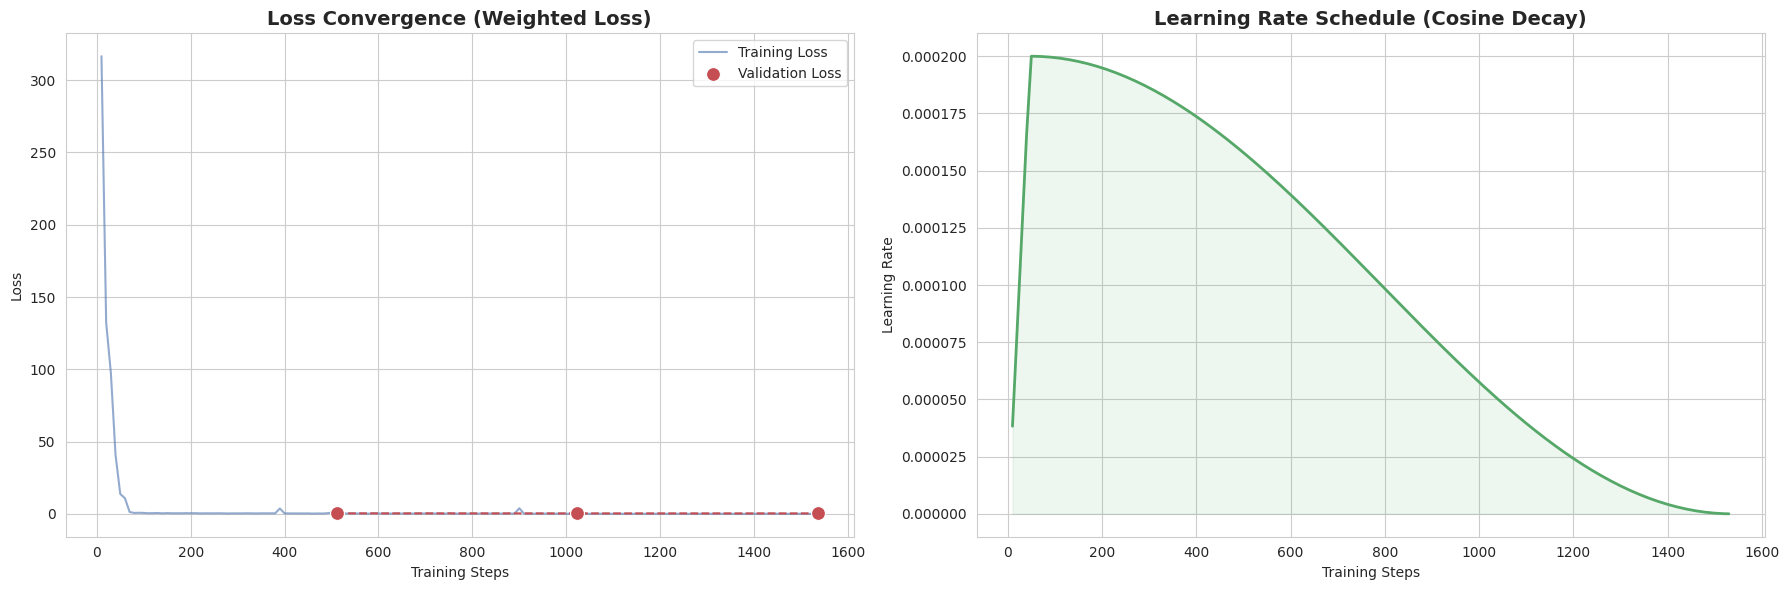

INTERPRETATION:
1. If Training Loss < Validation Loss: The model is memorizing (Overfitting).
2. If Validation Loss plateaus: Further training yields diminishing returns.
3. Note the Weighted Loss scale: Values are higher than standard LM loss due to the 5x classification penalty.


In [ ]:
# @title 8. Training Dynamics Analysis (The "Journey")
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("Analyzing Training Dynamics...")

# 1. Load Logs
log_path = os.path.join(dirs['logs'], "trainer_state.json")
if os.path.exists(log_path):
    with open(log_path, "r") as f:
        data = json.load(f)

    # Extract history
    history = data['log_history']
    df_logs = pd.DataFrame(history)

    # Separate Training logs (frequent) from Eval logs (per epoch)
    train_logs = df_logs.dropna(subset=['loss']).reset_index()
    eval_logs = df_logs.dropna(subset=['eval_loss']).reset_index()

    print(f"   Found {len(train_logs)} training steps and {len(eval_logs)} evaluation points.")

    # 2. Plotting
    sns.set_style("whitegrid")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # Chart A: Loss Curve (The "Convergence")
    sns.lineplot(data=train_logs, x='step', y='loss', ax=ax1, label='Training Loss', color='#4C72B0', alpha=0.6)
    # Overlay Validation Loss dots
    if not eval_logs.empty:
        sns.scatterplot(data=eval_logs, x='step', y='eval_loss', ax=ax1, color='#C44E52', s=100, label='Validation Loss', zorder=5)
        sns.lineplot(data=eval_logs, x='step', y='eval_loss', ax=ax1, color='#C44E52', linestyle='--')

    ax1.set_title("Loss Convergence (Weighted Loss)", fontsize=14, fontweight='bold')
    ax1.set_xlabel("Training Steps")
    ax1.set_ylabel("Loss")
    ax1.legend()

    # Chart B: Learning Rate (The "Schedule")
    if 'learning_rate' in train_logs.columns:
        sns.lineplot(data=train_logs, x='step', y='learning_rate', ax=ax2, color='#55A868', linewidth=2)
        ax2.set_title("Learning Rate Schedule (Cosine Decay)", fontsize=14, fontweight='bold')
        ax2.set_xlabel("Training Steps")
        ax2.set_ylabel("Learning Rate")
        ax2.fill_between(train_logs['step'], train_logs['learning_rate'], color='#55A868', alpha=0.1)

    plt.tight_layout()
    plt.savefig(os.path.join(dirs['results'], "training_dynamics.png"))
    plt.show()

    print("INTERPRETATION:")
    print("1. If Training Loss < Validation Loss: The model is memorizing (Overfitting).")
    print("2. If Validation Loss plateaus: Further training yields diminishing returns.")
    print("3. Note the Weighted Loss scale: Values are higher than standard LM loss due to the 5x classification penalty.")

else:
    print("No training logs found. Did training finish successfully?")

In [ ]:
# @title 9. Model Inference, Scores & Live Stress Test
import numpy as np
import gc
import torch
import os
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from tqdm.auto import tqdm
from peft import get_peft_model, LoraConfig

# 1. Clean Memory
if 'trainer' in locals(): del trainer
if 'model_wrapper' in locals(): del model_wrapper
gc.collect()
torch.cuda.empty_cache()

print("Loading Best Model for Inference...")

# 2. Reconstruct Architecture
inference_model = GemmaMultiTask(
    STUDENT_MODEL_ID,
    TASKS_CONFIG,
    loss_weights=CONFIG['loss_weights'],
    quantization=CONFIG['training']['quantization']
)
peft_config = LoraConfig(
    task_type="CAUSAL_LM", inference_mode=True, r=CONFIG['lora']['r'],
    lora_alpha=CONFIG['lora']['alpha'], lora_dropout=CONFIG['lora']['dropout'],
    target_modules=CONFIG['lora']['targets']
)
inference_model.base_model = get_peft_model(inference_model.base_model, peft_config)

# 3. Load Weights
adapter_path = os.path.join(dirs['adapter'], "pytorch_model.bin")
if os.path.exists(adapter_path):
    inference_model.load_state_dict(torch.load(adapter_path, map_location=DEVICE), strict=False)

head_path = dirs['heads']
if os.path.exists(head_path):
    inference_model.heads.load_state_dict(torch.load(head_path, map_location=DEVICE))
    inference_model.heads.to(dtype=BNB_DTYPE, device=DEVICE)

inference_model.to(DEVICE)
inference_model.eval()

# 4. Inference on Test Set
print("Running Inference on Test Data...")
predictions = {task: [] for task in TASKS_CONFIG}
ground_truths = {task: [] for task in TASKS_CONFIG}
confidences = {task: [] for task in TASKS_CONFIG}

test_loader = torch.utils.data.DataLoader(
    eval_dataset,
    batch_size=4,
    collate_fn=MultiTaskDataCollator(tokenizer, max_len=CONFIG['training']['max_seq_len'])
)

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = inference_model(**batch)
        for task in TASKS_CONFIG:
            probs = torch.softmax(outputs[f"logits_{task}"], dim=-1)
            preds = torch.argmax(probs, dim=-1).cpu().numpy()
            labels = batch[f"label_{task}"].cpu().numpy()
            batch_conf = torch.max(probs, dim=-1).values.float().cpu().numpy()

            valid = labels != -100
            predictions[task].extend(preds[valid])
            ground_truths[task].extend(labels[valid])
            confidences[task].extend(batch_conf[valid])

# 5. Performance Report
print("\n" + "="*40)
print("       PERFORMANCE REPORT       ")
print("="*40)
metrics_data = {}

for task in TASKS_CONFIG:
    y_true = ground_truths[task]
    y_pred = predictions[task]
    acc = accuracy_score(y_true, y_pred)
    _, _, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    metrics_data[task] = f1
    print(f"🔹 {task.upper().replace('_', ' ')}")
    print(f"   Accuracy: {acc:.2%}")
    print(f"   F1 Score: {f1:.4f}")
    print("-" * 40)

# 6. Live Stress Test (Now safely inside the cell where model exists)
print("\n--- PHASE 1 LIVE STRESS TEST ---")
custom_complaint = {
    "text": "I ordered the blue running shoes in size 10, but you sent me red sandals in size 8! This is ridiculous, I have a marathon tomorrow. I want my money back immediately.",
    "product_title": "Nike Air Zoom Pegasus 39", "price": 120.00, "rating": 1
}
formatted = format_multitask_sample({**custom_complaint, "is_actionable": 0, "info_complete": 0, "complaint_category": "N/A", "resolution_recommendation": "N/A"})
prompt_text = formatted['text_for_lm'].split("<start_of_turn>model")[0] + "<start_of_turn>model\n"
inputs = tokenizer(prompt_text, return_tensors="pt").to(DEVICE)

print(f"\nInput Prompt:\n{'-'*20}\n{prompt_text.strip()}\n{'-'*20}\n")

with torch.no_grad():
    outputs = inference_model(input_ids=inputs.input_ids, attention_mask=inputs.attention_mask)
    print("Model Thinking (Classification Heads):")
    for task in TASKS_CONFIG:
        logit = outputs[f"logits_{task}"][0]
        pred_idx = torch.argmax(logit).item()
        pred_label = TASKS_CONFIG[task]['labels'][pred_idx]
        confidence = torch.softmax(logit, dim=0)[pred_idx].item()
        icon = "✅" if confidence > 0.8 else "⚠️"
        print(f"   • {task.upper():<25} -> {pred_label:<25} ({confidence:.1%} {icon})")

    print("\nGenerating JSON...")
    gen_tokens = inference_model.base_model.generate(**inputs, max_new_tokens=64, do_sample=False)
    print(f"\n{tokenizer.decode(gen_tokens[0], skip_special_tokens=True).split('model\\n')[-1]}")

Loading Best Model for Inference...
Model Architecture: Base Gemma + 4 Classification Heads
Running Inference on Test Data...


Testing:   0%|          | 0/114 [00:00<?, ?it/s]


       PERFORMANCE REPORT       
🔹 IS ACTIONABLE
   Accuracy: 100.00%
   F1 Score: 1.0000
----------------------------------------
🔹 INFO COMPLETE
   Accuracy: 99.78%
   F1 Score: 0.9978
----------------------------------------
🔹 COMPLAINT CATEGORY
   Accuracy: 99.51%
   F1 Score: 0.9951
----------------------------------------
🔹 RESOLUTION RECOMMENDATION
   Accuracy: 99.76%
   F1 Score: 0.9976
----------------------------------------

--- PHASE 1 LIVE STRESS TEST ---

Input Prompt:
--------------------
<start_of_turn>user
Analyze this Amazon Fashion complaint:
Product: Nike Air Zoom Pegasus 39
Price: $120.00
Rating: 1/5
Complaint: "I ordered the blue running shoes in size 10, but you sent me red sandals in size 8! This is ridiculous, I have a marathon tomorrow. I want my money back immediately."
<end_of_turn>
<start_of_turn>model
--------------------

Model Thinking (Classification Heads):
   • IS_ACTIONABLE             -> 1                         (100.0% ✅)
   • INFO_COMPLETE      

Generating Phase 1 Confusion Matrices...


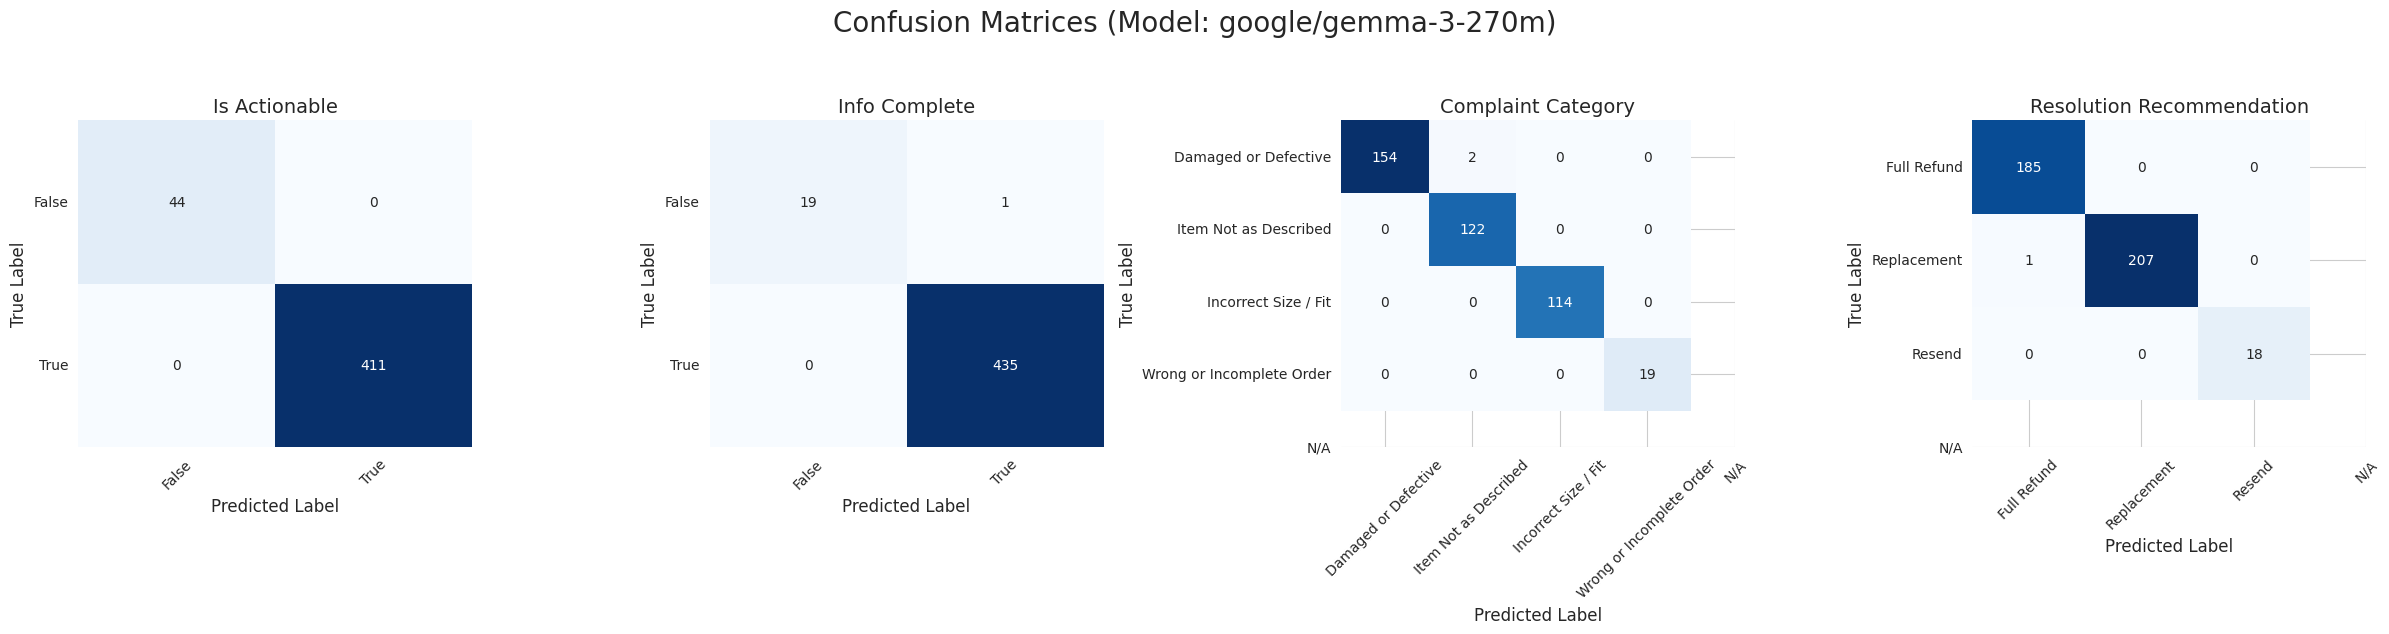

Generating Phase 1 Radar Chart...


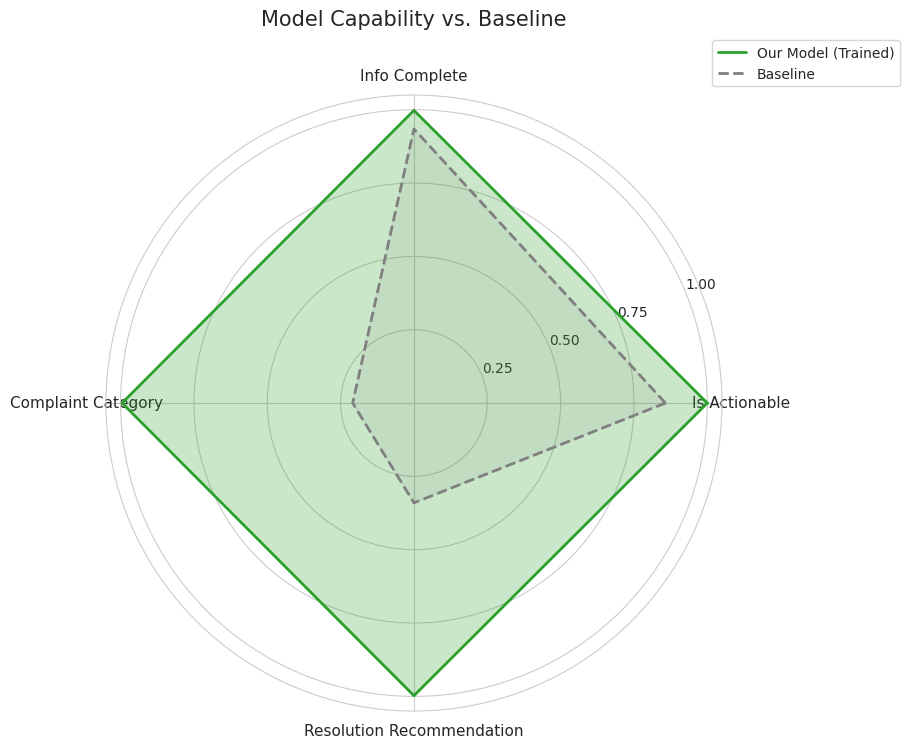

In [ ]:
# @title 9.5. Visualizations (Matrices & Radar Chart)
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
from collections import Counter

sns.set_style("whitegrid")

# 1. Confusion Matrices
print("Generating Phase 1 Confusion Matrices...")
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
fig.suptitle(f"Confusion Matrices (Model: {STUDENT_MODEL_ID})", fontsize=20, y=1.05)

for i, task in enumerate(TASKS_CONFIG):
    y_true = ground_truths[task]
    y_pred = predictions[task]
    labels = TASKS_CONFIG[task]['labels']

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=labels, yticklabels=labels, cbar=False)

    axes[i].set_title(task.replace('_', ' ').title(), fontsize=14)
    axes[i].set_xlabel('Predicted Label', fontsize=12)
    axes[i].set_ylabel('True Label', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45, labelsize=10)
    axes[i].tick_params(axis='y', rotation=0, labelsize=10)

plt.tight_layout()
plt.show()

# 2. Radar Chart
print("Generating Phase 1 Radar Chart...")
baseline_scores = []
for task in TASKS_CONFIG:
    y_true = ground_truths[task]
    counts = Counter(y_true)
    majority_class = counts.most_common(1)[0][0]
    y_baseline = [majority_class] * len(y_true)
    _, _, f1_base, _ = precision_recall_fscore_support(y_true, y_baseline, average='weighted', zero_division=0)
    baseline_scores.append(f1_base)

labels = [t.replace('_', ' ').title() for t in TASKS_CONFIG]
model_scores = list(metrics_data.values())
labels_closed = labels + [labels[0]]
model_scores_closed = model_scores + [model_scores[0]]
baseline_closed = baseline_scores + [baseline_scores[0]]
angles = np.linspace(0, 2*np.pi, len(labels_closed), endpoint=True).tolist()

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.plot(angles, model_scores_closed, color='#2ca02c', linewidth=2, label='Our Model (Trained)')
ax.fill(angles, model_scores_closed, color='#2ca02c', alpha=0.25)
ax.plot(angles, baseline_closed, color='#7f7f7f', linewidth=2, linestyle='--', label='Baseline')
ax.fill(angles, baseline_closed, color='#7f7f7f', alpha=0.1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, size=11)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_ylim(0, 1.05)
ax.set_title("Model Capability vs. Baseline", size=15, y=1.1)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

In [ ]:
# @title 10. Phase 2: Efficiency Optimization Training (Strict Early Stopping)
import traceback
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback

print("Initiating Phase 2: Efficiency Optimization Run...")

# 1. Clean Memory
if 'trainer' in locals(): del trainer
if 'model_wrapper' in locals(): del model_wrapper
if 'inference_model' in locals(): del inference_model
gc.collect()
torch.cuda.empty_cache()

# 2. Setup Output Directory
OUTPUT_DIR_V2 = os.path.join(NOTEBOOK_DIR, f"gemma-multitask-v{run_version}_optimized")
dirs_v2 = {
    "model": OUTPUT_DIR_V2,
    "adapter": os.path.join(OUTPUT_DIR_V2, "lora_adapter"),
    "heads": os.path.join(OUTPUT_DIR_V2, "classification_heads.pth"),
    "tokenizer": os.path.join(OUTPUT_DIR_V2, "tokenizer"),
    "logs": os.path.join(OUTPUT_DIR_V2, "logs"),
}
for d in dirs_v2.values():
    if not d.endswith('.pth'): os.makedirs(d, exist_ok=True)

# 3. Re-instantiate Fresh Model
print("Restoring fresh model weights...")
model_v2 = GemmaMultiTask(STUDENT_MODEL_ID, TASKS_CONFIG, CONFIG['loss_weights'], CONFIG['training']['quantization'])
peft_config = LoraConfig(
    task_type="CAUSAL_LM", inference_mode=False, r=CONFIG['lora']['r'],
    lora_alpha=CONFIG['lora']['alpha'], lora_dropout=CONFIG['lora']['dropout'],
    target_modules=CONFIG['lora']['targets']
)
model_v2.base_model = get_peft_model(model_v2.base_model, peft_config)
model_v2.base_model.enable_input_require_grads()
model_v2.gradient_checkpointing_enable()

# 4. Optimized Training Arguments
training_args_v2 = TrainingArguments(
    output_dir=dirs_v2['logs'],
    per_device_train_batch_size=CONFIG['training']['batch_size'],
    gradient_accumulation_steps=CONFIG['training']['grad_accum'],
    learning_rate=CONFIG['training']['lr'],
    num_train_epochs=CONFIG['training']['epochs'],
    optim="paged_adamw_8bit",

    # --- OPTIMIZATION SETTINGS ---
    save_strategy="steps",
    eval_strategy="steps",
    eval_steps=50,       # Frequent checks (every ~10% of an epoch)
    save_steps=50,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    # -----------------------------

    logging_steps=10,
    bf16=True,
    max_grad_norm=CONFIG['training']['max_grad_norm'],
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    group_by_length=False,
    report_to="none",
    ddp_find_unused_parameters=False,
    remove_unused_columns=False,
    label_names=["labels"] + [f"label_{t}" for t in TASKS_CONFIG.keys()],
    save_safetensors=False
)

trainer_v2 = Trainer(
    model=model_v2,
    args=training_args_v2,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
    data_collator=MultiTaskDataCollator(tokenizer, max_len=CONFIG['training']['max_seq_len']),

    # CRITICAL UPGRADE: Strict Early Stopping
    # patience=3: Wait 3 evaluation cycles (150 steps)
    # threshold=0.01: The loss must improve by at least 0.01 to count.
    # If loss goes 0.355 -> 0.354, it ignores it and the patience counter ticks down.
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3, early_stopping_threshold=0.01)]
)

print("🔥 Starting Optimized Training (Strict Stopping)...")
try:
    train_result_v2 = trainer_v2.train()
    print("\nTraining Completed.")

    trainer_v2.save_model(dirs_v2['adapter'])
    torch.save(model_v2.heads.state_dict(), dirs_v2['heads'])
    tokenizer.save_pretrained(dirs_v2['tokenizer'])
    trainer_v2.save_state()

except Exception as e:
    print(f"Training Failed: {e}")
    traceback.print_exc()

Initiating Phase 2: Efficiency Optimization Run...
Restoring fresh model weights...
Model Architecture: Base Gemma + 4 Classification Heads


/tmp/ipython-input-837018279.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_v2 = Trainer(


🔥 Starting Optimized Training (Strict Stopping)...


Step,Training Loss,Validation Loss
50,36.982100,2.144543
100,0.681700,0.553836
150,0.597700,0.521112
200,0.445200,0.606916
250,0.396900,0.574510
300,0.351900,0.517496


There were unexpected keys in the checkpoint model loaded: ['base_model.base_model.model.model.layers.0.self_attn.q_proj.base_layer.weight.absmax', 'base_model.base_model.model.model.layers.0.self_attn.q_proj.base_layer.weight.quant_map', 'base_model.base_model.model.model.layers.0.self_attn.q_proj.base_layer.weight.nested_absmax', 'base_model.base_model.model.model.layers.0.self_attn.q_proj.base_layer.weight.nested_quant_map', 'base_model.base_model.model.model.layers.0.self_attn.q_proj.base_layer.weight.quant_state.bitsandbytes__nf4', 'base_model.base_model.model.model.layers.0.self_attn.k_proj.base_layer.weight.absmax', 'base_model.base_model.model.model.layers.0.self_attn.k_proj.base_layer.weight.quant_map', 'base_model.base_model.model.model.layers.0.self_attn.k_proj.base_layer.weight.nested_absmax', 'base_model.base_model.model.model.layers.0.self_attn.k_proj.base_layer.weight.nested_quant_map', 'base_model.base_model.model.model.layers.0.self_attn.k_proj.base_layer.weight.quant_


Training Completed.


Analyzing Phase 2 Dynamics...
   Steps Trained: 300 / 1533
   COMPUTE SAVED: 80.4%


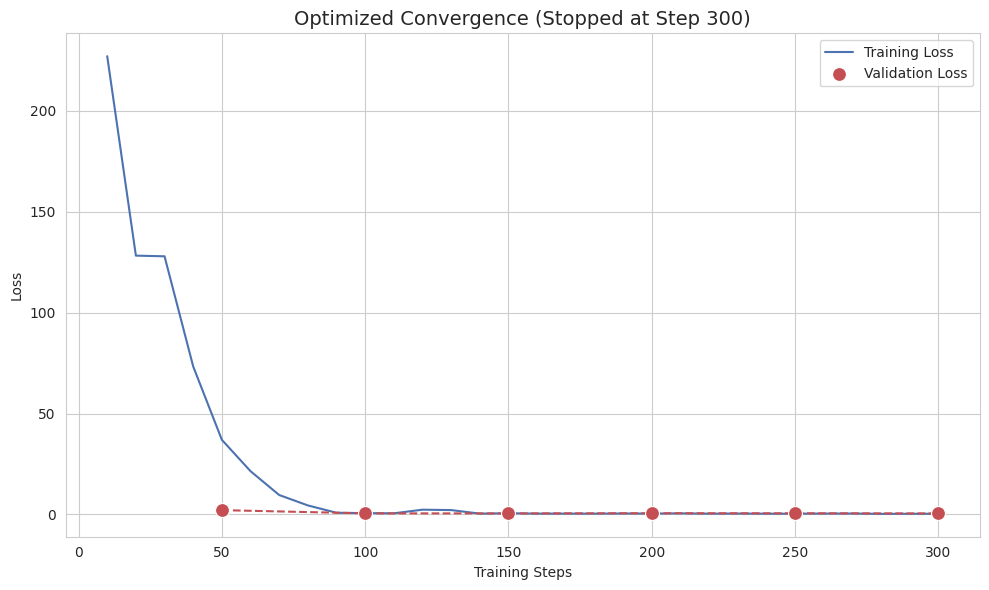

In [ ]:
# @title 11. Training Dynamics Analysis (Phase 2)
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("Analyzing Phase 2 Dynamics...")

log_path = os.path.join(dirs_v2['logs'], "trainer_state.json")
if os.path.exists(log_path):
    with open(log_path, "r") as f:
        data = json.load(f)

    history = data['log_history']
    df_logs = pd.DataFrame(history)
    train_logs = df_logs.dropna(subset=['loss']).reset_index()
    eval_logs = df_logs.dropna(subset=['eval_loss']).reset_index()

    # Calculate Savings
    total_planned_steps = (len(train_dataset) // (CONFIG['training']['batch_size'] * CONFIG['training']['grad_accum'])) * CONFIG['training']['epochs']
    actual_steps = train_logs['step'].iloc[-1]
    savings = (1 - (actual_steps / total_planned_steps)) * 100

    print(f"   Steps Trained: {actual_steps} / {total_planned_steps}")
    print(f"   COMPUTE SAVED: {savings:.1f}%")

    sns.set_style("whitegrid")
    plt.figure(figsize=(10, 6))

    sns.lineplot(data=train_logs, x='step', y='loss', label='Training Loss', color='#4C72B0')
    if not eval_logs.empty:
        sns.scatterplot(data=eval_logs, x='step', y='eval_loss', color='#C44E52', s=100, label='Validation Loss', zorder=5)
        sns.lineplot(data=eval_logs, x='step', y='eval_loss', color='#C44E52', linestyle='--')

    plt.title(f"Optimized Convergence (Stopped at Step {actual_steps})", fontsize=14)
    plt.xlabel("Training Steps")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
# @title 12. Inference, Performance Scores & Stress Test (Phase 2 Model)
import numpy as np
import torch
import os
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from tqdm.auto import tqdm
from peft import get_peft_model, LoraConfig

print("Loading Optimized Model for Inference...")

# 1. Reconstruct Architecture
inference_model_v2 = GemmaMultiTask(
    STUDENT_MODEL_ID,
    TASKS_CONFIG,
    loss_weights=CONFIG['loss_weights'],
    quantization=CONFIG['training']['quantization']
)
peft_config = LoraConfig(
    task_type="CAUSAL_LM", inference_mode=True, r=CONFIG['lora']['r'],
    lora_alpha=CONFIG['lora']['alpha'], lora_dropout=CONFIG['lora']['dropout'],
    target_modules=CONFIG['lora']['targets']
)
inference_model_v2.base_model = get_peft_model(inference_model_v2.base_model, peft_config)

# 2. Load V2 Weights
adapter_path = os.path.join(dirs_v2['adapter'], "pytorch_model.bin")
head_path = dirs_v2['heads']

if os.path.exists(adapter_path) and os.path.exists(head_path):
    inference_model_v2.load_state_dict(torch.load(adapter_path, map_location=DEVICE), strict=False)
    inference_model_v2.heads.load_state_dict(torch.load(head_path, map_location=DEVICE))
    inference_model_v2.heads.to(dtype=BNB_DTYPE, device=DEVICE)
    inference_model_v2.to(DEVICE)
    inference_model_v2.eval()

    # 3. Run Inference on Test Set
    print("Running Inference on Test Data...")
    preds_v2 = {t: [] for t in TASKS_CONFIG}
    truths_v2 = {t: [] for t in TASKS_CONFIG}

    test_loader = torch.utils.data.DataLoader(
        eval_dataset,
        batch_size=4,
        collate_fn=MultiTaskDataCollator(tokenizer, max_len=CONFIG['training']['max_seq_len'])
    )

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Testing V2"):
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = inference_model_v2(**batch)
            for task in TASKS_CONFIG:
                probs = torch.softmax(outputs[f"logits_{task}"], dim=-1)
                p = torch.argmax(probs, dim=-1).cpu().numpy()
                l = batch[f"label_{task}"].cpu().numpy()
                valid = l != -100
                preds_v2[task].extend(p[valid])
                truths_v2[task].extend(l[valid])

    # 4. Performance Report
    metrics_data_v2 = {}
    print("\n" + "="*40)
    print("    PHASE 2 PERFORMANCE REPORT (V2)     ")
    print("="*40)
    for task in TASKS_CONFIG:
        acc = accuracy_score(truths_v2[task], preds_v2[task])
        _, _, f1, _ = precision_recall_fscore_support(truths_v2[task], preds_v2[task], average='weighted', zero_division=0)
        metrics_data_v2[task] = f1
        print(f"TASK: {task.upper()}")
        print(f"   Accuracy: {acc:.2%}")
        print(f"   F1 Score: {f1:.4f}")
        print("-" * 40)

    # 5. Live Stress Test (V2)
    print("\n--- PHASE 2 LIVE STRESS TEST (Consistency Check) ---")
    custom_complaint = {
        "text": "I ordered the blue running shoes in size 10, but you sent me red sandals in size 8! This is ridiculous, I have a marathon tomorrow. I want my money back immediately.",
        "product_title": "Nike Air Zoom Pegasus 39", "price": 120.00, "rating": 1
    }
    formatted = format_multitask_sample({**custom_complaint, "is_actionable": 0, "info_complete": 0, "complaint_category": "N/A", "resolution_recommendation": "N/A"})
    prompt_text = formatted['text_for_lm'].split("<start_of_turn>model")[0] + "<start_of_turn>model\n"
    inputs = tokenizer(prompt_text, return_tensors="pt").to(DEVICE)

    print(f"\nInput Prompt:\n{'-'*20}\n{prompt_text.strip()}\n{'-'*20}\n")

    with torch.no_grad():
        outputs = inference_model_v2(input_ids=inputs.input_ids, attention_mask=inputs.attention_mask)
        print("Optimized Model Thinking (Classification Heads):")
        for task in TASKS_CONFIG:
            logit = outputs[f"logits_{task}"][0]
            pred_idx = torch.argmax(logit).item()
            pred_label = TASKS_CONFIG[task]['labels'][pred_idx]
            confidence = torch.softmax(logit, dim=0)[pred_idx].item()
            print(f"   • {task.upper():<25} -> {pred_label:<25} ({confidence:.1%})")

        print("\nGenerating JSON (Optimized Model)...")
        gen_tokens = inference_model_v2.base_model.generate(**inputs, max_new_tokens=64, do_sample=False)
        print(f"\n{tokenizer.decode(gen_tokens[0], skip_special_tokens=True).split('model\\n')[-1]}")

else:
    print("V2 Weights not found. Did Phase 2 training finish?")

Loading Optimized Model for Inference...
Model Architecture: Base Gemma + 4 Classification Heads
Running Inference on Test Data...


Testing V2:   0%|          | 0/114 [00:00<?, ?it/s]


    PHASE 2 PERFORMANCE REPORT (V2)     
TASK: IS_ACTIONABLE
   Accuracy: 99.12%
   F1 Score: 0.9914
----------------------------------------
TASK: INFO_COMPLETE
   Accuracy: 99.78%
   F1 Score: 0.9978
----------------------------------------
TASK: COMPLAINT_CATEGORY
   Accuracy: 99.51%
   F1 Score: 0.9951
----------------------------------------
TASK: RESOLUTION_RECOMMENDATION
   Accuracy: 99.03%
   F1 Score: 0.9907
----------------------------------------

--- PHASE 2 LIVE STRESS TEST (Consistency Check) ---

Input Prompt:
--------------------
<start_of_turn>user
Analyze this Amazon Fashion complaint:
Product: Nike Air Zoom Pegasus 39
Price: $120.00
Rating: 1/5
Complaint: "I ordered the blue running shoes in size 10, but you sent me red sandals in size 8! This is ridiculous, I have a marathon tomorrow. I want my money back immediately."
<end_of_turn>
<start_of_turn>model
--------------------

Optimized Model Thinking (Classification Heads):
   • IS_ACTIONABLE             -> 0       

Generating Phase 2 Visualizations...


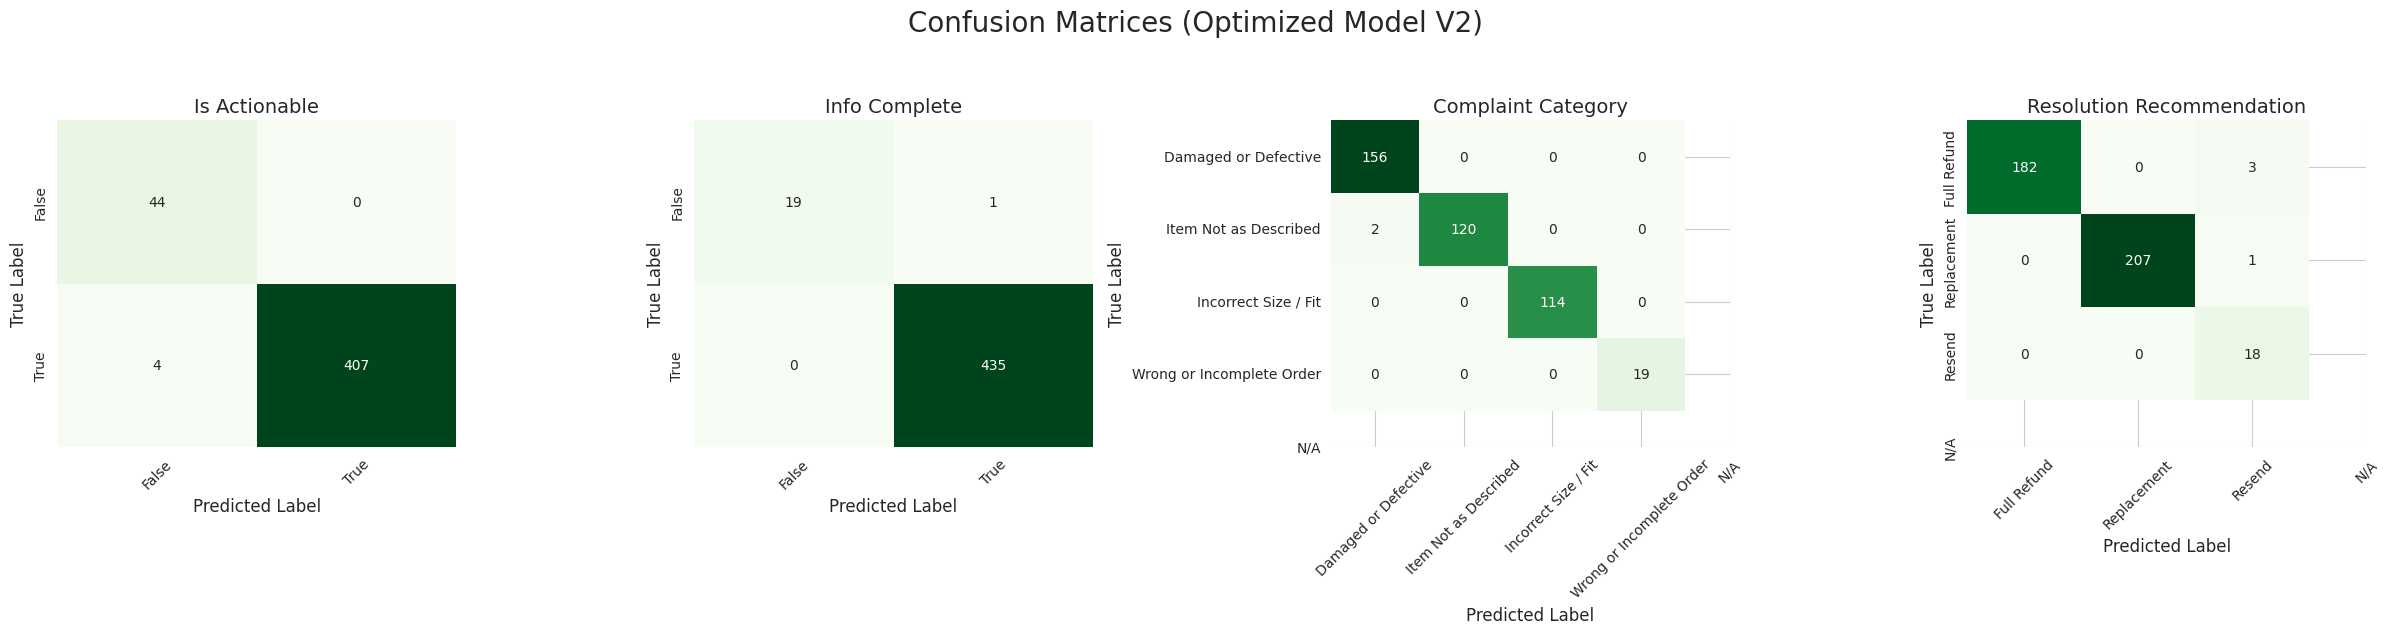

Generating Phase 2 Radar Chart...


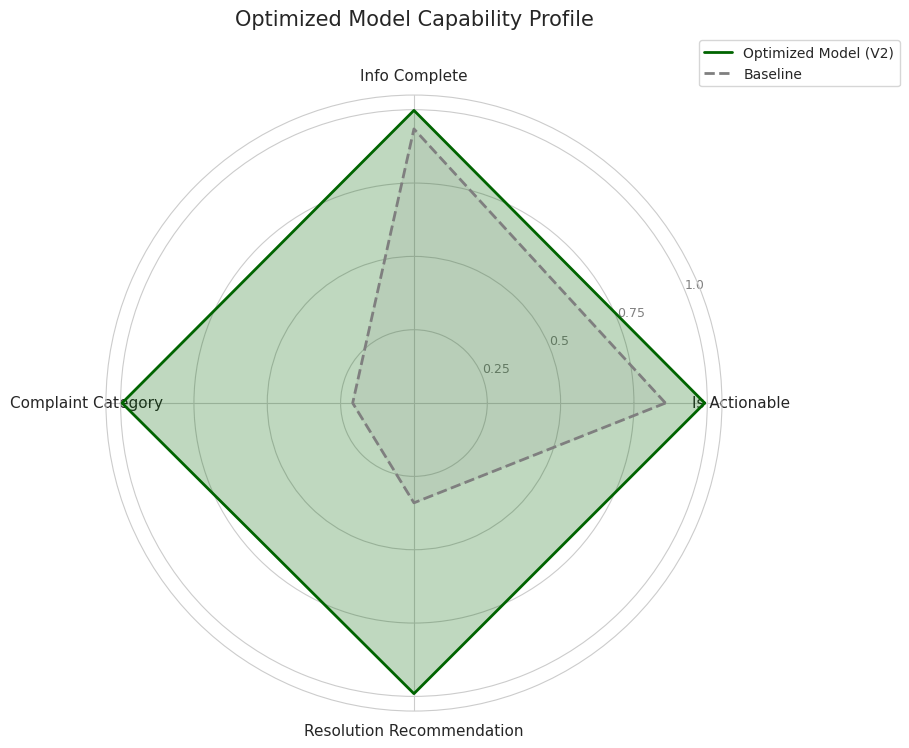

In [ ]:
# @title 12.5. Visualizations (Phase 2: Matrices & Radar)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
from collections import Counter

print("Generating Phase 2 Visualizations...")
sns.set_style("whitegrid")

# --- 1. Confusion Matrices ---
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
fig.suptitle(f"Confusion Matrices (Optimized Model V2)", fontsize=20, y=1.05)

for i, task in enumerate(TASKS_CONFIG):
    cm = confusion_matrix(truths_v2[task], preds_v2[task])
    labels = TASKS_CONFIG[task]['labels']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[i],
                xticklabels=labels, yticklabels=labels, cbar=False)
    axes[i].set_title(task.replace('_', ' ').title(), fontsize=14)
    axes[i].set_xlabel('Predicted Label', fontsize=12)
    axes[i].set_ylabel('True Label', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# --- 2. Radar Chart (Phase 2) ---
print("Generating Phase 2 Radar Chart...")

# Calculate Baseline Scores (Same dataset, same baseline)
baseline_v2 = []
labels = [t.replace('_', ' ').title() for t in TASKS_CONFIG]

for task in TASKS_CONFIG:
    y_true = truths_v2[task]
    counts = Counter(y_true)
    majority_class = counts.most_common(1)[0][0]
    y_base = [majority_class] * len(y_true)
    _, _, f1_base, _ = precision_recall_fscore_support(y_true, y_base, average='weighted', zero_division=0)
    baseline_v2.append(f1_base)

# Prepare Geometry
model_scores = list(metrics_data_v2.values()) # From Cell 12
labels_closed = labels + [labels[0]]
metrics_closed = model_scores + [model_scores[0]]
baseline_closed = baseline_v2 + [baseline_v2[0]]
angles = np.linspace(0, 2*np.pi, len(labels_closed), endpoint=True).tolist()

# Plot
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Plot V2 Model (Dark Green)
ax.plot(angles, metrics_closed, color='#006400', linewidth=2, label='Optimized Model (V2)')
ax.fill(angles, metrics_closed, color='#006400', alpha=0.25)

# Plot Baseline (Grey)
ax.plot(angles, baseline_closed, color='#7f7f7f', linewidth=2, linestyle='--', label='Baseline')
ax.fill(angles, baseline_closed, color='#7f7f7f', alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, size=11)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0.25", "0.5", "0.75", "1.0"], color="grey", size=9)
ax.set_ylim(0, 1.05)
ax.set_title("Optimized Model Capability Profile", size=15, y=1.1)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.show()